# EDA: Anti-UAV RGBT dataset

Аналіз датасету перед тренуванням YOLO-детектора: цілісність спліту train/val/test, розподіл розмірів bounding box-ів та частка негативних (без цілі) кадрів.

In [5]:
import re
from pathlib import Path
from typing import Set, Tuple

import numpy as np
import matplotlib.pyplot as plt

DATA_ROOT = Path("../Anti-UAV-RGBT")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"
YOLO_DIR = DATA_ROOT / "yolo_dataset"

## 1. Цілісність спліту (split integrity)

Перевіряємо перетин train/val/test не лише на рівні назв послідовностей (тек), а й на рівні базової **сесії запису**. Назва послідовності має вигляд `YYYYMMDD_HHMMSS_N_M`, де `YYYYMMDD_HHMMSS_N` — базова сесія (той самий захід зйомки: фон, освітлення, дрон, траєкторія), а завершальний `_M` — індекс окремого кліпу/камери в межах цієї сесії.

**Результат:** назви послідовностей між train і val не перетинаються жодного разу, але на рівні базової сесії перетин майже повний — **26 з 27** train-сесій одночасно присутні й у val. Тобто val складається переважно з інших кліпів тих самих записів, що й train (спільний фон, освітлення, часто той самий дрон і траєкторія) — це витік даних (data leakage), і метрики на val будуть завищеними відносно реальної узагальнювальної здатності моделі. На противагу цьому, test не перетинається з train/val на жодному рівні — цей спліт чистий і надійний для фінальної оцінки.

In [6]:
def base_session_id(seq_name: str) -> str:
    return re.sub(r"_\d+$", "", seq_name)


def seq_names(dir_path: Path) -> Set[str]:
    return {p.name for p in dir_path.iterdir() if p.is_dir()}


def session_ids(dir_path: Path) -> Set[str]:
    return {base_session_id(name) for name in seq_names(dir_path)}


train_seqs, val_seqs, test_seqs = seq_names(TRAIN_DIR), seq_names(VAL_DIR), seq_names(TEST_DIR)
train_sessions, val_sessions, test_sessions = (
    session_ids(TRAIN_DIR),
    session_ids(VAL_DIR),
    session_ids(TEST_DIR),
)

print(f"train: {len(train_seqs)} послідовностей, {len(train_sessions)} унікальних сесій")
print(f"val:   {len(val_seqs)} послідовностей, {len(val_sessions)} унікальних сесій")
print(f"test:  {len(test_seqs)} послідовностей, {len(test_sessions)} унікальних сесій")
print()
print(f"Перетин назв послідовностей train/val: {len(train_seqs & val_seqs)}")
print(
    f"Перетин базових сесій train/val: {len(train_sessions & val_sessions)} "
    f"з {len(train_sessions)} train-сесій"
)
print(f"Перетин базових сесій train/test: {len(train_sessions & test_sessions)}")
print(f"Перетин базових сесій val/test: {len(val_sessions & test_sessions)}")

sorted(train_sessions & val_sessions)

train: 160 послідовностей, 27 унікальних сесій
val:   67 послідовностей, 26 унікальних сесій
test:  91 послідовностей, 10 унікальних сесій

Перетин назв послідовностей train/val: 0
Перетин базових сесій train/val: 26 з 27 train-сесій
Перетин базових сесій train/test: 0
Перетин базових сесій val/test: 0


['20190925_101846_1',
 '20190925_130434_1',
 '20190925_131530_1',
 '20190925_133630_1',
 '20190925_140917_1',
 '20190925_141417_1',
 '20190925_143900_1',
 '20190925_152412_1',
 '20190925_183946_1',
 '20190925_194211_1',
 '20190925_200320_1',
 '20190925_205804_1',
 '20190925_210802_1',
 '20190925_213001_1',
 '20190925_222534_1',
 '20190926_103046_1',
 '20190926_130341_1',
 '20190926_133516_1',
 '20190926_141816_1',
 '20190926_142435_1',
 '20190926_143632_1',
 '20190926_144550_1',
 '20190926_183400_1',
 '20190926_183941_1',
 '20190926_195921_1',
 '20190926_200510_1']

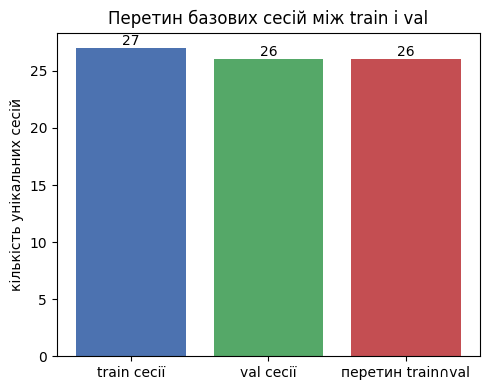

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
labels = ["train сесії", "val сесії", "перетин train\u2229val"]
values = [len(train_sessions), len(val_sessions), len(train_sessions & val_sessions)]
ax.bar(labels, values, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("кількість унікальних сесій")
ax.set_title("Перетин базових сесій між train і val")
for i, v in enumerate(values):
    ax.text(i, v + 0.3, str(v), ha="center")
plt.tight_layout()
plt.show()

## 2. Розподіл розмірів bounding box-ів та частка малих об'єктів

Розмір кадру в `yolo_dataset` фіксований — 640×512 px. Для train і val окремо обчислюємо ширину/висоту bbox-ів у пікселях, aspect ratio та частку "малих об'єктів" за визначенням COCO (площа < 32×32 px).

In [ ]:
IMG_W, IMG_H = 640, 512
SMALL_OBJECT_PX = 32


def load_boxes(labels_dir: Path) -> Tuple[np.ndarray, np.ndarray]:
    ws, hs = [], []
    for f in labels_dir.glob("*.txt"):
        for line in f.read_text().splitlines():
            parts = line.split()
            if len(parts) == 5:
                _, _, _, w, h = parts
                ws.append(float(w) * IMG_W)
                hs.append(float(h) * IMG_H)
    return np.array(ws), np.array(hs)


train_w, train_h = load_boxes(YOLO_DIR / "labels" / "train")
val_w, val_h = load_boxes(YOLO_DIR / "labels" / "val")

train_area, val_area = train_w * train_h, val_w * val_h
train_ar, val_ar = train_w / train_h, val_w / val_h


def summarize(name: str, w: np.ndarray, h: np.ndarray, area: np.ndarray) -> None:
    small_frac = (area < SMALL_OBJECT_PX**2).mean() * 100
    print(
        f"{name}: n={len(w)}, медіана w={np.median(w):.1f}px h={np.median(h):.1f}px, "
        f"медіана area={np.median(area):.0f}px², "
        f"малих об'єктів (<{SMALL_OBJECT_PX}x{SMALL_OBJECT_PX}): {small_frac:.1f}%"
    )


summarize("train", train_w, train_h, train_area)
summarize("val", val_w, val_h, val_area)

train: n=15632, медіана w=46.0px h=27.0px, медіана area=1240px², малих об'єктів (<32x32): 36.1%
val: n=16065, медіана w=44.0px h=28.0px, медіана area=1260px², малих об'єктів (<32x32): 33.3%


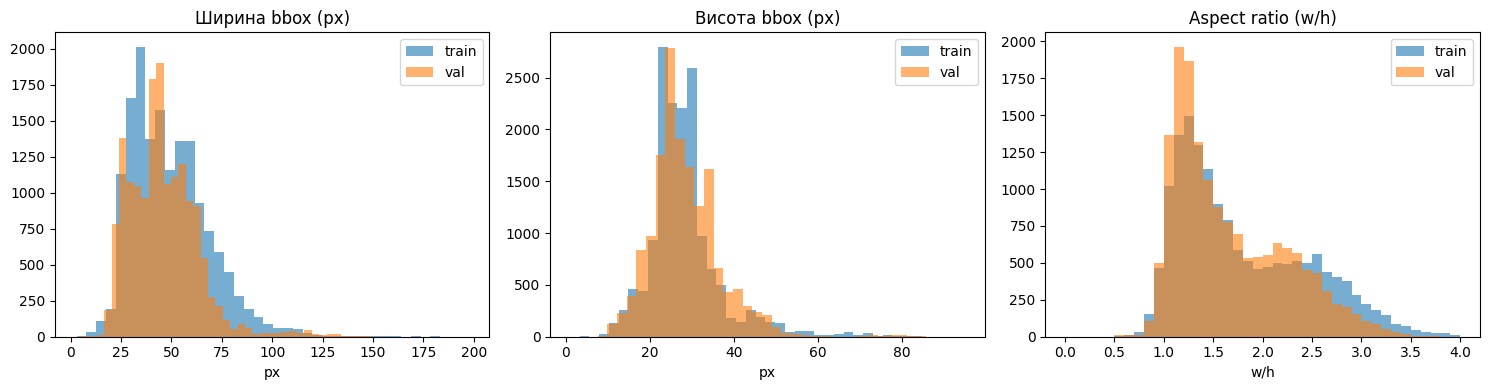

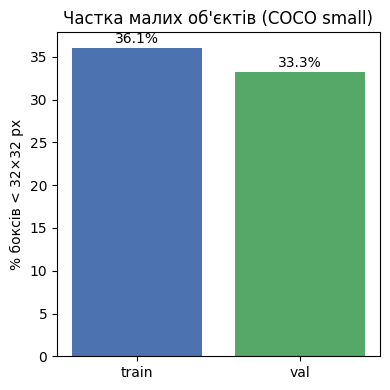

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(train_w, bins=40, alpha=0.6, label="train")
axes[0].hist(val_w, bins=40, alpha=0.6, label="val")
axes[0].set_title("Ширина bbox (px)")
axes[0].set_xlabel("px")
axes[0].legend()

axes[1].hist(train_h, bins=40, alpha=0.6, label="train")
axes[1].hist(val_h, bins=40, alpha=0.6, label="val")
axes[1].set_title("Висота bbox (px)")
axes[1].set_xlabel("px")
axes[1].legend()

axes[2].hist(train_ar, bins=40, range=(0, 4), alpha=0.6, label="train")
axes[2].hist(val_ar, bins=40, range=(0, 4), alpha=0.6, label="val")
axes[2].set_title("Aspect ratio (w/h)")
axes[2].set_xlabel("w/h")
axes[2].legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4, 4))
fracs = [
    (train_area < SMALL_OBJECT_PX**2).mean() * 100,
    (val_area < SMALL_OBJECT_PX**2).mean() * 100,
]
ax.bar(["train", "val"], fracs, color=["#4C72B0", "#55A868"])
ax.set_ylabel(f"% боксів < {SMALL_OBJECT_PX}\u00d7{SMALL_OBJECT_PX} px")
ax.set_title("Частка малих об'єктів (COCO small)")
for i, v in enumerate(fracs):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()

**Висновок:** дрон у кадрі здебільшого дуже дрібний (медіана ~46×27 px на кадрі 640×512), і значна частка боксів (>30%) підпадає під поріг "малого об'єкта". Це напряму впливає на вибір розміру вхідного зображення та вибір моделі/anchor-стратегії, орієнтованої на детекцію малих об'єктів.

## 3. Частка негативних кадрів (без цілі) по train/val

Негативний кадр — це кадр, для якого відповідний label-файл у `yolo_dataset/labels` порожній (ціль відсутня у кадрі, наприклад дрон вилетів за межі поля зору).

In [10]:
def negative_ratio(labels_dir: Path) -> Tuple[int, int, float]:
    files = list(labels_dir.glob("*.txt"))
    empty = sum(1 for f in files if f.stat().st_size == 0)
    return empty, len(files), empty / len(files) * 100


train_empty, train_total, train_neg_pct = negative_ratio(YOLO_DIR / "labels" / "train")
val_empty, val_total, val_neg_pct = negative_ratio(YOLO_DIR / "labels" / "val")

print(f"train: {train_empty}/{train_total} негативних кадрів ({train_neg_pct:.1f}%)")
print(f"val:   {val_empty}/{val_total} негативних кадрів ({val_neg_pct:.1f}%)")

train: 1177/16809 негативних кадрів (7.0%)
val:   1403/17468 негативних кадрів (8.0%)


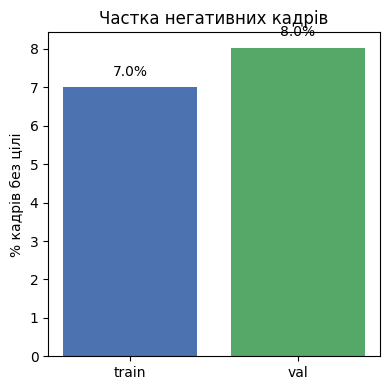

In [11]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(["train", "val"], [train_neg_pct, val_neg_pct], color=["#4C72B0", "#55A868"])
ax.set_ylabel("% кадрів без цілі")
ax.set_title("Частка негативних кадрів")
for i, v in enumerate([train_neg_pct, val_neg_pct]):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()

**Висновок:** частка негативних кадрів у train і val приблизно однакова (~7-8%), тож систематичного перекосу тут немає. Однак чи підвищити кількість негативних кадрів чи ні, щоб модель правильно розпізнавала відсутність обʼєкта в кадрі, покажуть перші результати.